# Computing the collision probabilities of different unique DNA molecules into the same consensus molecule via equal cuts and equal tagging

### How to compute required input

#### (optional) 0. Sort the files in case they are not sorted
This might not be needed for the immediate next step but might be useful for exploring some example cases

```
# in case you want to resort the BAM file
samtools sort -@ 7 P_6_2_J_1.sorted.bam -o P_6_2_J_1.resorted.bam --write-index
```

#### 1. Starting from a BAM file you can run this 
This will report for each read which is the starting and end position of the alignment.

```
for file in $(ls *.sorted.bam); do
  sample=${file%.bam}
  echo "$sample"

  samtools view -@ 15 ${sample}.bam | \
  awk '
  function cigar_len(cigar,   len,op,total) {
      total=0
      while (match(cigar, /[0-9]+[MIDNSHP=X]/)) {
          len=substr(cigar, RSTART, RLENGTH-1)
          op=substr(cigar, RSTART+RLENGTH-1, 1)
          if (op ~ /[MDN=X]/) total += len
          cigar=substr(cigar, RSTART+RLENGTH)
      }
      return total
  }

  BEGIN{OFS="\t"}

  {
    chr=$3
    pos=$4
    cigar=$6

    if (chr=="*" || cigar=="*") next

    len = cigar_len(cigar)
    end = pos + len - 1

    print $1, chr, pos, end
  }' | gzip > ${sample}.read_coords.tsv.gz

done
```


#### 2. Merge the information of each pair of reads and report how many times a given set of cuts is unique
```
for file in $(ls *_2.sorted.bam | cut -d '.' -f1); do
echo $file;
python /data/bbg/projects/prominent/protocols/paper_figures/supplementary_analysis/UMIcollisions/compute_unique_cuts_freq.py $file /data/bbg/nobackup2/prominent/duplex_seq_tests/error_rate/cord_blood/bbg/2026-03-17_tws_idt ;
done;
```

Example of output:

```
$ zcat SC001_B1_1_H_2.sorted.read_coords.cuts_freq.tsv.gz
repeats	frequency
1	46,353,191
2	2,430,718
3	254,679
4	37,477
5	7,193
6	1,687
7	485
8	191
9	80
10	39
11	19
12	9
14	6
16	3
13	2
18	1
17	1
```


In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import brentq

import matplotlib.pyplot as plt

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
run = "/data/bbg/nobackup2/prominent/duplex_seq_tests/error_rate/cord_blood/bbg/2026-03-17_tws_idt"

In [3]:
cord_blood_samples_list = ["SC003_B1_1_H_1", "SC002_B1_1_H_1", "SC001_B1_1_H_1",
                           "SC003_B1_1_H_2", "SC002_B1_1_H_2", "SC001_B1_1_H_2"]
reference_sample = "SC001_B1_1_H_2"


## Read cut frequency files and plot them

In [4]:
all_counts_df = pd.DataFrame()
for file in os.listdir(f"{run}/processing_files/sortbamamfiltered/"):
    if file.endswith(".sorted.read_coords.cuts_freq.tsv.gz"):
        print(file)
        sample = file.split('.')[0]
        sample_counts = pd.read_csv(f"{run}/processing_files/sortbamamfiltered/{file}", sep="\t")
        sample_counts["sample"] = sample
        sample_counts["relative_frequency"] = sample_counts["frequency"] / sample_counts["frequency"].sum()
        # sample_counts["expected_poisson_cuts"] = (sample_counts["relative_frequency"] * sample_counts["repeats"]).sum()
        all_counts_df = pd.concat([all_counts_df, sample_counts], ignore_index=True)


SC002_B1_1_H_2.sorted.read_coords.cuts_freq.tsv.gz
SC001_B1_1_H_2.sorted.read_coords.cuts_freq.tsv.gz
SC003_B1_1_H_2.sorted.read_coords.cuts_freq.tsv.gz
SC001_B1_1_H_1.sorted.read_coords.cuts_freq.tsv.gz
SC002_B1_1_H_1.sorted.read_coords.cuts_freq.tsv.gz
SC003_B1_1_H_1.sorted.read_coords.cuts_freq.tsv.gz


In [5]:
all_counts_df["total_fragments"] = all_counts_df["repeats"] * all_counts_df["frequency"]
all_counts_df["repeated"] = all_counts_df["repeats"] > 1
repeated_frequency = all_counts_df.groupby(by = ["sample", "repeated"])["total_fragments"].sum()
repeated_frequency

sample          repeated
SC001_B1_1_H_1  False       72605095
                True         9930665
SC001_B1_1_H_2  False       46353191
                True         5828011
SC002_B1_1_H_1  False       91013953
                True        13236728
SC002_B1_1_H_2  False       57106533
                True         8601399
SC003_B1_1_H_1  False       97322864
                True        14360079
SC003_B1_1_H_2  False       68727524
                True        15478474
Name: total_fragments, dtype: int64

In [6]:
all_counts_df.head(20)

,repeats,frequency,sample,relative_frequency,total_fragments,repeated
0,1,57106533,SC002_B1_1_H_2,9.348416e-01,57106533,False
1,2,3463947,SC002_B1_1_H_2,5.670528e-02,6927894,True
2,3,424075,SC002_B1_1_H_2,6.942164e-03,1272225,True
3,4,70498,SC002_B1_1_H_2,1.154062e-03,281992,True
4,5,15412,SC002_B1_1_H_2,2.522965e-04,77060,True
5,6,4239,SC002_B1_1_H_2,6.939300e-05,25434,True
6,7,1288,SC002_B1_1_H_2,2.108473e-05,9016,True
7,8,502,SC002_B1_1_H_2,8.217807e-06,4016,True
8,9,176,SC002_B1_1_H_2,2.881144e-06,1584,True
9,10,76,SC002_B1_1_H_2,1.244130e-06,760,True


## UMI counts

In [7]:
def get_single_umi_probabilities_vector(sample, run, plot = False, verbose=False):
    umi_counts_data = pd.read_table(f"{run}/metrics/duplex/fgbio_seqmetricsontarget/{sample}_chr1.on_target.duplex_seq_metrics.umi_counts.txt")
    umi_counts_data = umi_counts_data.sort_values("fraction_unique_observations", ascending = False).reset_index(drop=True)
    umi_counts_data["cummulative_fraction"] = umi_counts_data["fraction_unique_observations"].cumsum()

    # identify the elbow point in the cumulative distribution of UMIs to determine a cutoff for high-frequency UMIs
    init_val = 1
    i = 0
    diff = 0
    while diff < (init_val / 2):
        new_val = umi_counts_data.loc[i,"fraction_unique_observations"]
        if verbose:
            print(i, new_val, init_val)
        if i == 0:
            init_val = umi_counts_data.loc[i,"fraction_unique_observations"]
        else:
            diff = init_val - umi_counts_data.loc[i,"fraction_unique_observations"]
        init_val = umi_counts_data.loc[i,"fraction_unique_observations"]
        if verbose:
            print(diff)
        i += 1

    umi_tag_probabilities = umi_counts_data.loc[:i-1,"fraction_unique_observations"].values
    umi_tag_probabilities_norm = umi_tag_probabilities / umi_tag_probabilities.sum()

    return i, umi_tag_probabilities, umi_tag_probabilities_norm


In [8]:
def get_duplex_umi_probabilities_vector(sample, run, size, plot = False, verbose=False):
    umi_counts_data = pd.read_table(f"{run}/metrics/duplex/fgbio_seqmetricsontarget/{sample}_chr1.on_target.duplex_seq_metrics.duplex_umi_counts.txt")
    umi_counts_data = umi_counts_data.sort_values("fraction_unique_observations", ascending = False).reset_index(drop=True)
    umi_counts_data["cummulative_fraction"] = umi_counts_data["fraction_unique_observations"].cumsum()

    umi_tag_probabilities = umi_counts_data.loc[:size,"fraction_unique_observations"].values
    umi_tag_probabilities_norm = umi_tag_probabilities / umi_tag_probabilities.sum()

    return umi_tag_probabilities, umi_tag_probabilities_norm


## Estimate UMI collisions

In [9]:
def posterior_expectation_one_repeat(p):
    """
    p: numpy array of probabilities
    """
    num = np.sum(p / ((1 - p)**2))
    den = np.sum(p / (1 - p))
    return num / den

# expected_N = posterior_expectation_one_repeat(p)
# expected_N

In [10]:
def func(N, p):
    """
    p: numpy array of probabilities
    N: number of independent trials
    """
    return np.sum(1 - (1 - p) ** N)


def find_N(p, target):
    """
    p: numpy array of probabilities
    target: target value for the sum
    """
    # Define a function that we want to find the root of
    def objective(N):
        return func(N, p) - target
    
    # Use brentq to find the root of the objective function
    N_solution = brentq(objective, 1, 1e6)  # Search for N in the range [1, 1e6]
    
    return N_solution

In [11]:
def compute_original_fragments_per_sample(counts_df, vector_of_probabilities):
    n_repeats_observed = counts_df["repeats"].unique().tolist()
    n_repeats_observed.remove(1)

    mapping_observed_repeats_to_original_cuts = {1: posterior_expectation_one_repeat(vector_of_probabilities).item()}
    
    for n_repeats in n_repeats_observed:
        N_solution = find_N(vector_of_probabilities, n_repeats)
        mapping_observed_repeats_to_original_cuts[n_repeats] = N_solution

    print(mapping_observed_repeats_to_original_cuts)
    return mapping_observed_repeats_to_original_cuts

In [12]:
def plot_umi_frequencies(x, type_of_umi = "duplex", sample = "sample"):
    data = pd.DataFrame(sorted(x, reverse=True))
    data.columns = ["frequency"]
    data = data.reset_index()

    # plot cumsumative distribution of duplex UMIs (fraction_raw_observations)
    sns.lineplot(data=data, x="index", y="frequency")
    plt.xlabel(f"{type_of_umi.capitalize()} UMI Rank")
    plt.ylabel("Fraction of Raw Observations")
    plt.title(f"{sample}\nCumulative Distribution of {type_of_umi.capitalize()} UMIs")
    # plt.xlim(-100, 15000)
    plt.show()

SC003_B1_1_H_1: main_UMI_tags	= 98


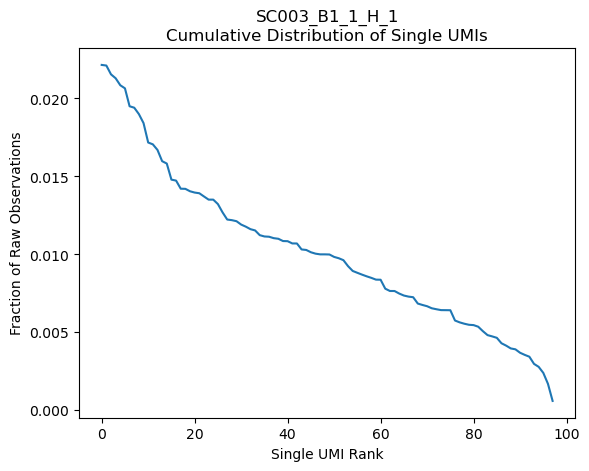

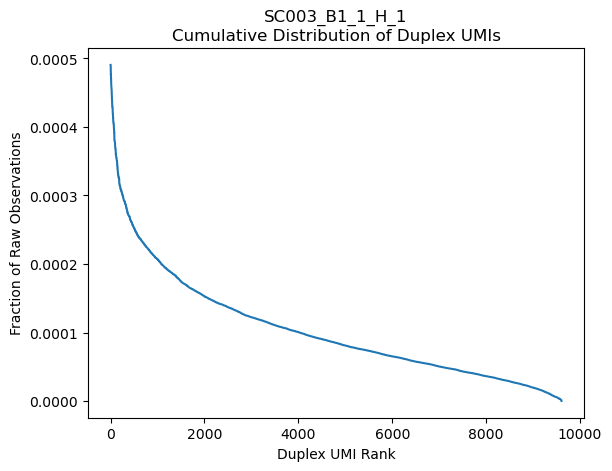

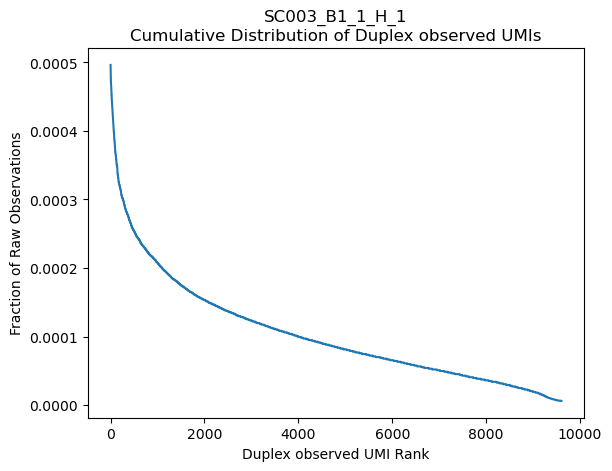

SC003_B1_1_H_1: D_eff		= 6187
{1: 1.0001616817081642, 2: 2.0001616764075414, 3: 3.000485072320577, 4: 4.000970230852479, 5: 5.00161719513258, 6: 6.002426008306886, 7: 7.003396713534943, 8: 8.004529353995002, 9: 9.005823972879549, 10: 10.007280613397308, 11: 11.00889931877295, 12: 12.010680132246982, 13: 13.012623097075855, 14: 14.014728256531914, 15: 15.016995653903448, 17: 17.022017335625726, 16: 16.019425332494677, 18: 18.024771706632702, 19: 19.027688488867646, 21: 21.034009460509417, 25: 25.048602247791, 22: 22.037413736700167, 20: 20.030767725698563, 23: 23.04098059768673, 24: 24.044710086901034, 34: 34.09095909803996, 31: 31.07537375342046, 26: 26.052657123820527, 27: 27.056874758469576, 30: 30.0705046491735, 28: 28.0612551952341}
SC003_B1_1_H_1: Lost fragments	= 17,264
SC003_B1_1_H_1: Lost proportion	= 0.02%

SC002_B1_1_H_1: main_UMI_tags	= 98


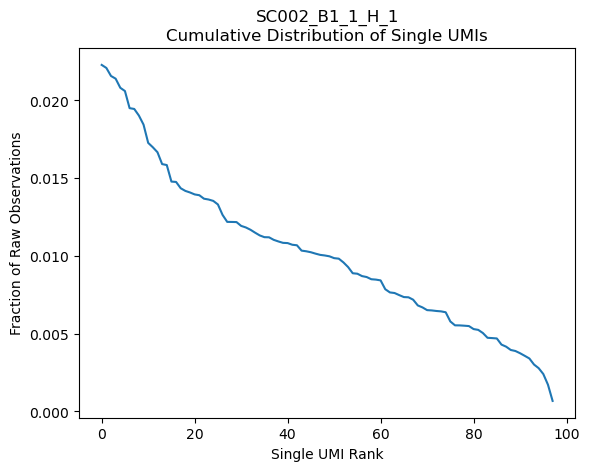

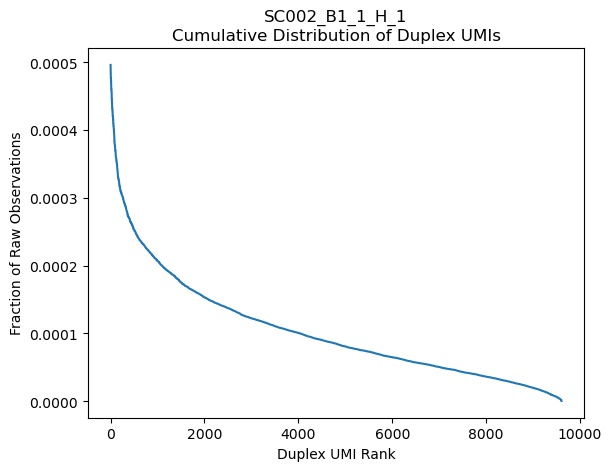

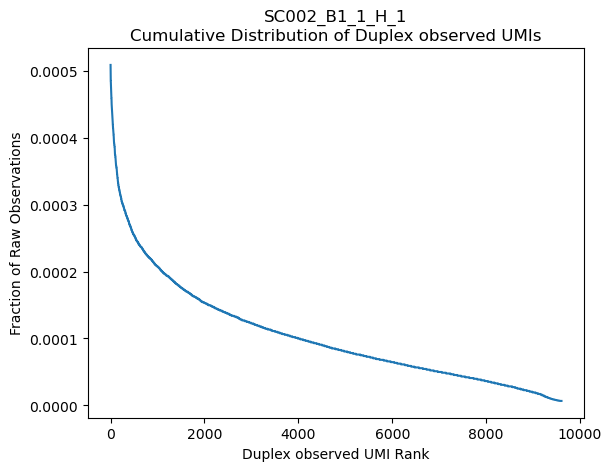

SC002_B1_1_H_1: D_eff		= 6170
{1: 1.0001621062963635, 2: 2.000162100914511, 3: 3.0004863460414333, 4: 4.000972778694191, 5: 5.001621442202192, 6: 6.002432379911682, 7: 7.003405635182518, 8: 8.004541251393333, 9: 9.00583927193711, 10: 10.007299740223175, 11: 11.008922699676864, 12: 12.01070819373945, 13: 13.01265626586825, 14: 14.014766959536585, 15: 15.0170403182338, 16: 16.019476385465225, 17: 17.02207520475228, 19: 19.027761273658907, 18: 18.02483681963234, 20: 20.0308486104015, 23: 23.041088352861642, 22: 22.037512106393176, 21: 21.034098873445714, 24: 24.044827656484905, 25: 25.0487300609129, 27: 27.05702434686311, 29: 29.065971560233667, 26: 26.052795609811596, 32: 32.08061738441543, 41: 41.13338592201112, 43: 43.146913435620434, 35: 35.09673426395155, 39: 39.1205137897089, 65: 65.33907199289989}
SC002_B1_1_H_1: Lost fragments	= 16,160
SC002_B1_1_H_1: Lost proportion	= 0.02%

SC001_B1_1_H_1: main_UMI_tags	= 98


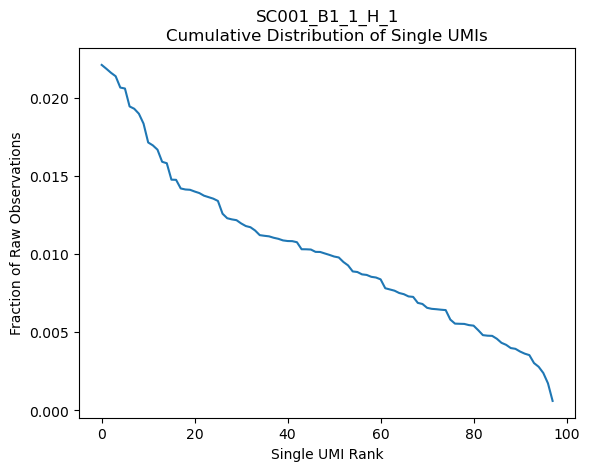

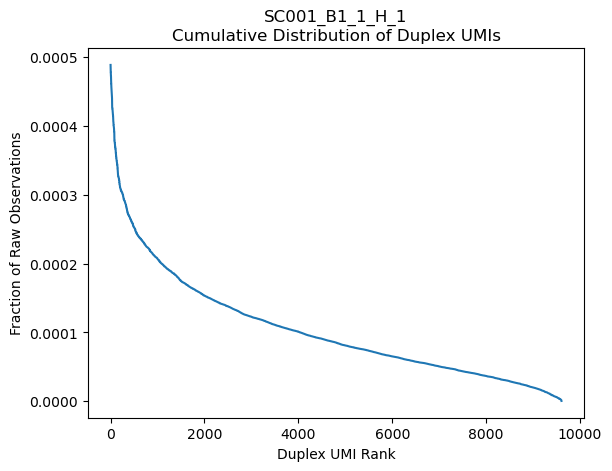

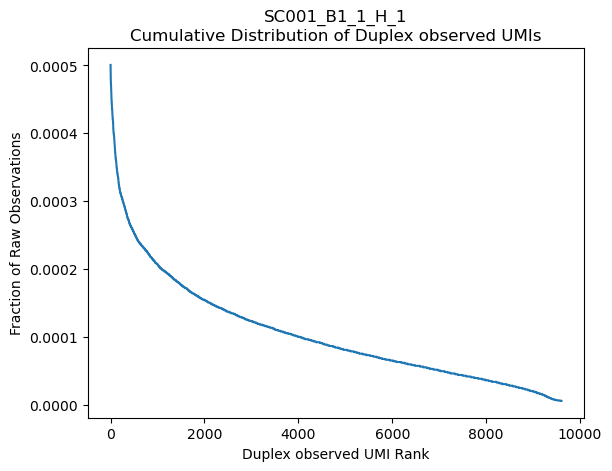

SC001_B1_1_H_1: D_eff		= 6193
{1: 1.0001615259605323, 2: 2.000161520841229, 3: 3.00048460562429, 4: 4.000969297465236, 5: 5.001615639496124, 6: 6.002423674865677, 7: 7.003393446736204, 8: 8.004524998288712, 9: 9.005818372718506, 10: 10.007273613237144, 11: 11.0088907630721, 12: 12.010669865466788, 13: 13.012610963680524, 14: 14.014714100988595, 15: 15.016979320682204, 16: 16.019406666068516, 17: 17.02199618047067, 18: 18.02474790722775, 20: 20.030738171242977, 23: 23.04094124432417, 21: 21.033976795259207, 19: 19.027661889694837, 24: 24.044667156226986, 25: 25.048555584306136, 22: 22.037377805146594, 31: 31.075301427764973, 26: 26.052606572028733, 30: 30.07043698925705, 39: 39.120082146727846, 33: 33.08551881070968}
SC001_B1_1_H_1: Lost fragments	= 12,758
SC001_B1_1_H_1: Lost proportion	= 0.02%

SC003_B1_1_H_2: main_UMI_tags	= 32


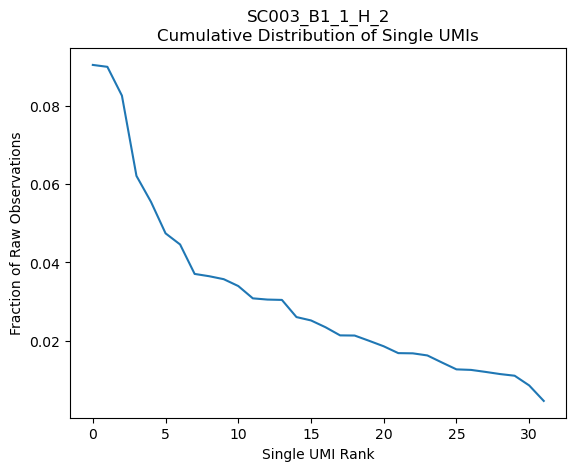

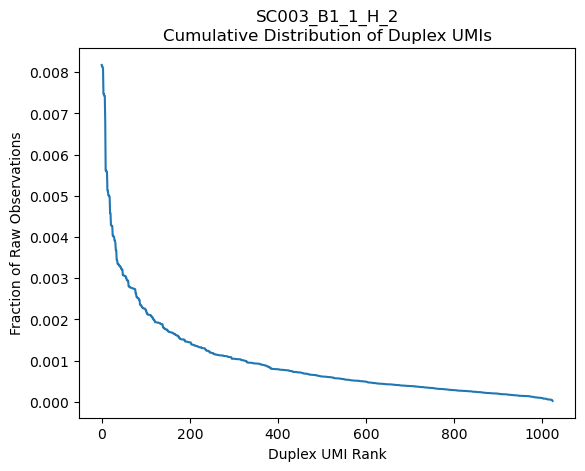

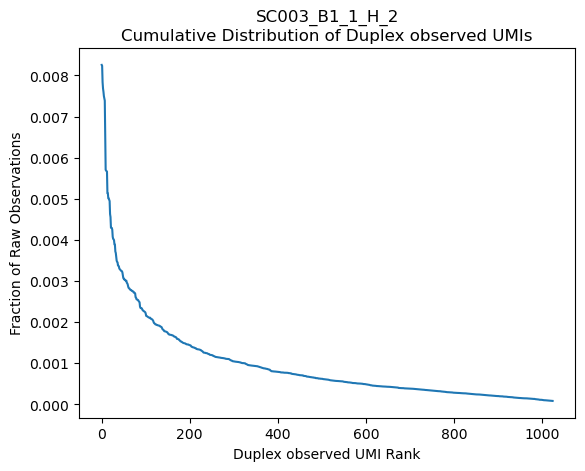

SC003_B1_1_H_2: D_eff		= 443
{1: 1.0022711630133867, 2: 2.0022657230900776, 3: 3.006803439694831, 4: 4.013619438468004, 5: 5.022720026359143, 6: 6.034111528687481, 7: 7.04780028921133, 8: 8.063792670200078, 9: 9.082095052506372, 10: 10.10271383563894, 11: 11.125655437834645, 12: 12.150926296135601, 13: 13.178532866459909, 14: 14.208481623678706, 15: 15.240779061691283, 16: 16.27543169350133, 17: 17.312446051293684, 18: 18.35182868651172, 20: 20.437725091759482, 23: 23.584496682479436, 22: 22.53317370894082, 19: 19.393586169935322, 24: 24.63822765094298, 21: 21.484252061673516, 39: 40.737747612182986, 74: 80.54840182729684, 25: 25.69437330280249, 33: 34.23127634200087, 26: 26.752940346428655}
SC003_B1_1_H_2: Lost fragments	= 181,371
SC003_B1_1_H_2: Lost proportion	= 0.21%

SC002_B1_1_H_2: main_UMI_tags	= 32


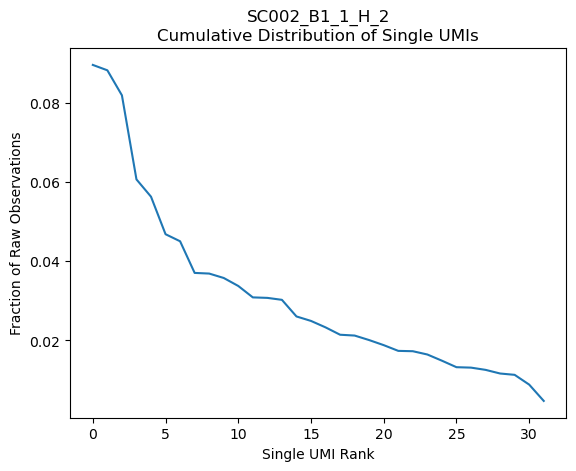

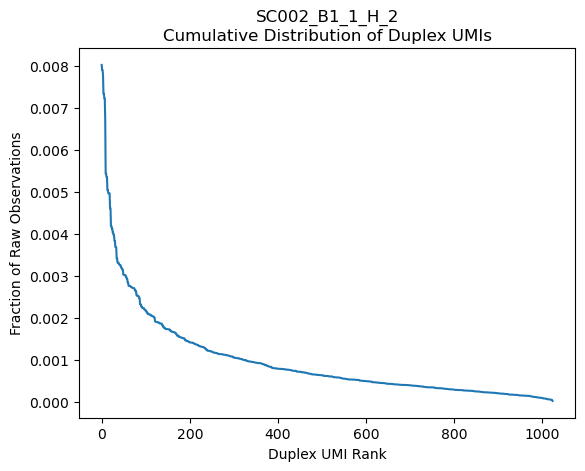

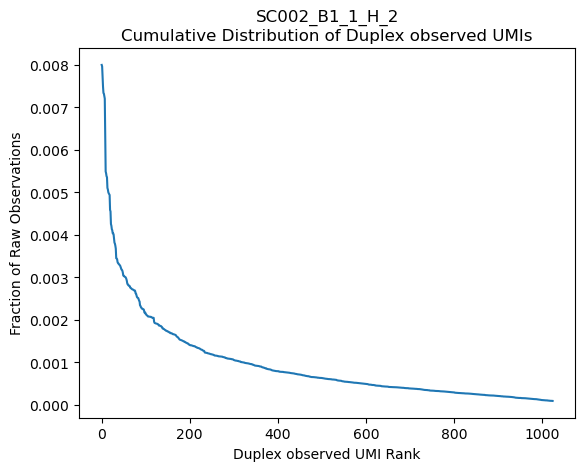

SC002_B1_1_H_2: D_eff		= 453
{1: 1.0022199892453114, 2: 2.0022149347292566, 3: 3.006650868744747, 4: 4.01331388441844, 5: 5.022210082003318, 6: 6.03334557970591, 7: 7.046726513754787, 8: 8.062359038471417, 9: 9.080249326341256, 10: 10.10040356808534, 11: 11.122827972731354, 12: 12.147528767688986, 13: 13.174512198819954, 15: 15.235352045759745, 14: 14.2037845305134, 16: 16.26922104622548, 25: 25.67865800282357, 17: 17.30539785232849, 23: 23.571278932647974, 21: 21.473310202035112, 20: 20.427838591508465}
SC002_B1_1_H_2: Lost fragments	= 138,824
SC002_B1_1_H_2: Lost proportion	= 0.21%

SC001_B1_1_H_2: main_UMI_tags	= 32


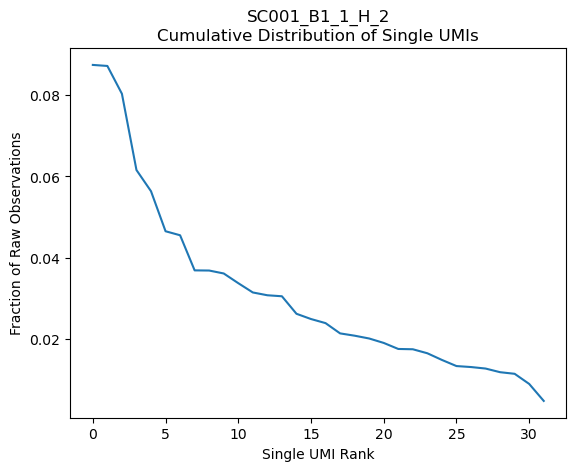

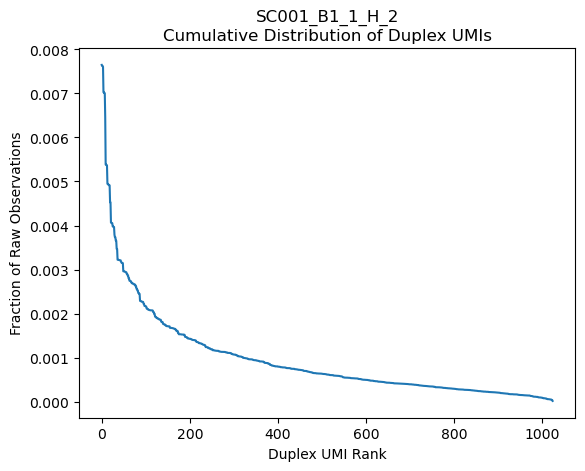

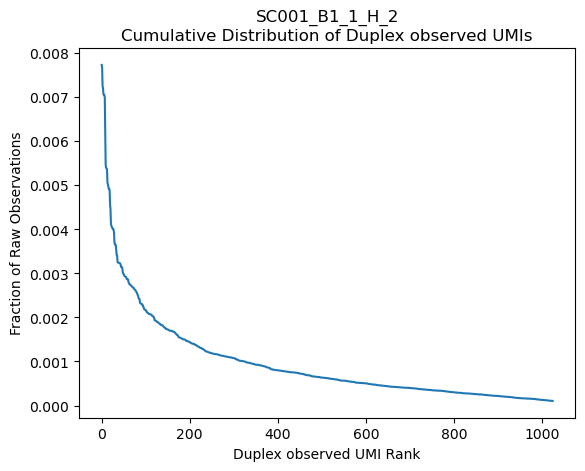

SC001_B1_1_H_2: D_eff		= 463
{1: 1.0021692685695935, 2: 2.0021647042646538, 3: 3.006500036971724, 4: 4.013011940145493, 5: 5.021706373723255, 6: 6.032589315627547, 7: 7.045666761834913, 8: 8.06094472644666, 9: 9.078429241759927, 10: 10.098126358339185, 11: 11.120042145087337, 12: 12.14418268932047, 14: 14.199162491998383, 16: 16.263114835912525, 13: 13.17055409683817, 18: 18.33608908990965, 17: 17.298471126840536}
SC001_B1_1_H_2: Lost fragments	= 108,219
SC001_B1_1_H_2: Lost proportion	= 0.21%



In [13]:
upd_counts_df = pd.DataFrame()
# compile all metrics in a single table
summary_stats = []
for sample in cord_blood_samples_list:

    unique_tags_number, umi_tag_probabilities, umi_tag_probabilities_norm = get_single_umi_probabilities_vector(sample, run, plot = False, verbose=False)

    print(f"{sample}: main_UMI_tags\t= {unique_tags_number}")
    tag_probabilities_assume_random_side = np.matmul(umi_tag_probabilities_norm.reshape(-1, 1), umi_tag_probabilities_norm.reshape(1, -1)).flatten()

    duplex_tag_probabilities, duplex_tag_probabilities_norm = get_duplex_umi_probabilities_vector(sample, run,
                                                                                                  size=unique_tags_number**2,
                                                                                                  verbose=False)

    vector_of_probabilities = tag_probabilities_assume_random_side
    # vector_of_probabilities = np.array([1/unique_tags_number**2] * unique_tags_number**2)

    plot_umi_frequencies(umi_tag_probabilities_norm, type_of_umi="single", sample=sample)
    plot_umi_frequencies(vector_of_probabilities, type_of_umi="duplex", sample=sample)
    plot_umi_frequencies(duplex_tag_probabilities_norm, type_of_umi="duplex observed", sample=sample)

    probability_of_same_tag_2_frag = np.sum(vector_of_probabilities ** 2)
    D_eff = 1 / probability_of_same_tag_2_frag
    print(f"{sample}: D_eff\t\t= {D_eff:.0f}")


    sample_count_df = all_counts_df[all_counts_df["sample"] == sample].copy()
    mapping_observed_repeats_to_original_cuts = compute_original_fragments_per_sample(sample_count_df, vector_of_probabilities)

    sample_count_df["original_fragments_per_cutsite"] = sample_count_df["repeats"].map(mapping_observed_repeats_to_original_cuts)
    sample_count_df["original_fragments"] = sample_count_df["original_fragments_per_cutsite"] * sample_count_df["frequency"]
    lost_fragments = sample_count_df["original_fragments"].sum() - sample_count_df["total_fragments"].sum()

    print(f"{sample}: Lost fragments\t= {lost_fragments:,.0f}")

    lost_proportion = lost_fragments / sample_count_df["original_fragments"].sum()

    print(f"{sample}: Lost proportion\t= {lost_proportion:.2%}")
    upd_counts_df = pd.concat([upd_counts_df, sample_count_df], ignore_index=True)
    summary_stats.append([sample, unique_tags_number, unique_tags_number**2, round(D_eff), round(lost_fragments), lost_proportion])

    print()


In [14]:
summary_stats_df = pd.DataFrame(summary_stats, columns=["sample", "unique_tags_number", "unique_tags_number_duplex", "D_eff",
                                                        "lost_fragments", "lost_proportion"])
summary_stats_df

,sample,unique_tags_number,unique_tags_number_duplex,D_eff,lost_fragments,lost_proportion
0,SC003_B1_1_H_1,98,9604,6187,17264,0.000155
1,SC002_B1_1_H_1,98,9604,6170,16160,0.000155
2,SC001_B1_1_H_1,98,9604,6193,12758,0.000155
3,SC003_B1_1_H_2,32,1024,443,181371,0.002149
4,SC002_B1_1_H_2,32,1024,453,138824,0.002108
5,SC001_B1_1_H_2,32,1024,463,108219,0.002070


## Exploration

### Plotting

In [15]:
# all_counts_df[all_counts_df["repeats"] > 20]

In [16]:
# sns.barplot(data=all_counts_df,
#              x="repeats",
#              y="relative_frequency",             
#              hue="sample",
#              dodge=True)
# # plt.yscale("log")
# plt.xlabel("Number of reads with identical cut sites")
# plt.ylabel("Relative frequency")
# plt.title("Frequency of identical cut sites across samples")
# plt.legend(title="Sample", bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

In [17]:
per_sample_repeated_frequency = repeated_frequency.unstack(fill_value=0)
per_sample_repeated_frequency = per_sample_repeated_frequency.div(per_sample_repeated_frequency.sum(axis=1), axis=0)
per_sample_repeated_frequency

repeated,False,True
sample,,
SC001_B1_1_H_1,0.879680,0.120320
SC001_B1_1_H_2,0.888312,0.111688
SC002_B1_1_H_1,0.873030,0.126970
SC002_B1_1_H_2,0.869096,0.130904
SC003_B1_1_H_1,0.871421,0.128579
SC003_B1_1_H_2,0.816183,0.183817


In [18]:
# umi_counts_data = pd.read_table(f"{run}/collectduplexseqmetricsontarget/{sample}_chr1.on_target.duplex_seq_metrics.umi_counts.txt")


#### Compute edit distances between tags

In [19]:
reference_sample = "SC001_B1_1_H_2"

In [20]:
umi_counts_data = pd.read_table(f"{run}/metrics/duplex/fgbio_seqmetricsontarget/{reference_sample}_chr1.on_target.duplex_seq_metrics.umi_counts.txt")
umi_counts_data = umi_counts_data.sort_values("fraction_unique_observations", ascending = False).reset_index(drop=True)
umi_sequences = umi_counts_data.iloc[:32]["umi"].values

In [21]:
# compute edit distance
def compute_edit_distance(seq1, seq2):
    if len(seq1) != len(seq2):
        raise ValueError("Sequences must be of the same length")
    return sum(el1 != el2 for el1, el2 in zip(seq1, seq2))
edit_distances = [compute_edit_distance(umi_sequences[i], umi_sequences[j]) for i in range(len(umi_sequences)) for j in range(len(umi_sequences))]  
edit_distance_matrix = pd.DataFrame([edit_distances[x:x+32] for x in range(0, len(edit_distances), 32)],
                                    index=[f"UMI_{i}" for i in range(1, 33)],
                                    columns=[f"UMI_{i}" for i in range(1, 33)]
                                    )

In [22]:
edit_distance_matrix

,UMI_1,UMI_2,UMI_3,UMI_4,UMI_5,UMI_6,UMI_7,UMI_8,UMI_9,UMI_10,...,UMI_23,UMI_24,UMI_25,UMI_26,UMI_27,UMI_28,UMI_29,UMI_30,UMI_31,UMI_32
UMI_1,0,6,4,4,5,5,3,5,6,6,...,5,8,8,5,8,7,5,6,6,6
UMI_2,6,0,5,4,7,6,7,6,5,4,...,7,6,7,7,8,4,5,5,7,6
UMI_3,4,5,0,5,6,4,6,3,5,5,...,6,7,5,4,7,6,8,6,5,8
UMI_4,4,4,5,0,5,5,3,5,6,7,...,8,6,8,8,6,5,6,7,7,4
UMI_5,5,7,6,5,0,4,3,3,5,6,...,6,6,7,7,7,8,7,7,6,6
UMI_6,5,6,4,5,4,0,6,7,6,6,...,6,5,5,6,7,8,8,5,8,7
UMI_7,3,7,6,3,3,6,0,4,5,7,...,7,7,8,6,6,7,6,7,6,5
UMI_8,5,6,3,5,3,7,4,0,5,6,...,7,8,6,6,7,6,7,7,4,7
UMI_9,6,5,5,6,5,6,5,5,0,5,...,6,4,5,6,4,5,7,6,4,5
UMI_10,6,4,5,7,6,6,7,6,5,0,...,4,6,5,5,8,5,6,4,5,6


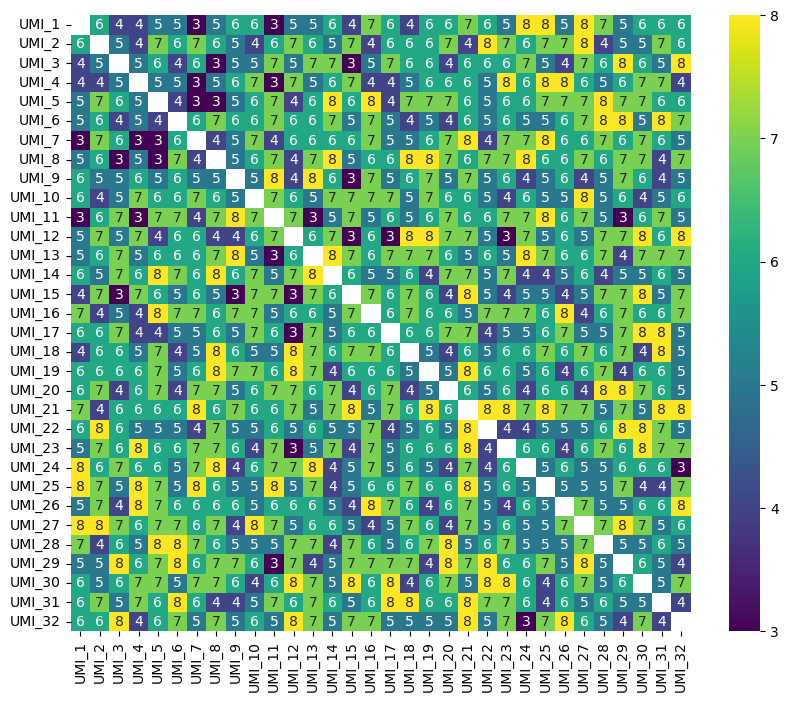

In [23]:
plt.figure(figsize=(10, 8))
sns.heatmap(edit_distance_matrix[edit_distance_matrix != 0], annot=True, cmap="viridis")
plt.xticks()
plt.show()

### Minor explorations

In [ ]:
reference_sample = "SC003_B1_1_H_1"

In [43]:
unique_tags_number, umi_tag_probabilities, umi_tag_probabilities_norm = get_single_umi_probabilities_vector(reference_sample, run, verbose=False)
umi_tag_probabilities_norm

array([0.02214566, 0.02210584, 0.02154079, 0.02129001, 0.0208412 ,
       0.02064424, 0.01949369, 0.01940113, 0.01899107, 0.0184131 ,
       0.01716784, 0.01705052, 0.01669212, 0.01597101, 0.01581818,
       0.01478602, 0.01472467, 0.01420482, 0.01419514, 0.01404015,
       0.01395728, 0.01391315, 0.0137065 , 0.01350416, 0.01350309,
       0.01321787, 0.01268618, 0.01222661, 0.01218679, 0.01211898,
       0.01190372, 0.01176919, 0.01160882, 0.01152702, 0.01122459,
       0.01114064, 0.01112342, 0.01103193, 0.01099211, 0.01084681,
       0.01083712, 0.0106929 , 0.01069075, 0.01030759, 0.0102753 ,
       0.01012785, 0.01003744, 0.00999224, 0.00999224, 0.00998363,
       0.00982864, 0.00974362, 0.00961877, 0.00923346, 0.00892779,
       0.00880833, 0.00869209, 0.00858338, 0.00848436, 0.00837135,
       0.00836382, 0.00779016, 0.00764271, 0.00764055, 0.00747804,
       0.00735103, 0.00728215, 0.00724341, 0.00683657, 0.00674616,
       0.00666544, 0.00653413, 0.00647171, 0.00641574, 0.00641

In [44]:
tag_probabilities_assume_random_side = np.matmul(umi_tag_probabilities_norm.reshape(-1, 1), umi_tag_probabilities_norm.reshape(1, -1)).flatten()
tag_probabilities_assume_random_side

array([4.90430363e-04, 4.89548466e-04, 4.77035055e-04, ...,
       1.40798344e-06, 9.94094713e-07, 3.47869670e-07], shape=(9604,))

In [45]:
vector_of_probabilities = tag_probabilities_assume_random_side

In [46]:
# Check loop to find exactly which n_repeats fails.
sample = reference_sample
sample_count_df = all_counts_df[all_counts_df["sample"] == sample].copy()
n_repeats_observed = sample_count_df["repeats"].unique().tolist()
for n in sorted(n_repeats_observed):
    f_1 = func(1, vector_of_probabilities) - n
    f_1e6 = func(1e6, vector_of_probabilities) - n
    if np.sign(f_1) == np.sign(f_1e6):
        print(f"Failed for n={n}: func(1)={f_1}, func(1e6)={f_1e6}")


Failed for n=1: func(1)=2.6645352591003757e-15, func(1e6)=9597.056380116792


Effective barcode diversity

In [ ]:
probability_of_same_tag_2_frag = np.sum(tag_probabilities_assume_random_side ** 2) 
D_eff = 1 / probability_of_same_tag_2_frag
D_eff

442.8599913741647

Failed for n=1: func(1)=4.440892098500626e-16, func(1e6)=1022.99999999938


## Duplex UMI counts

In [20]:
# umi_counts_data = pd.read_table(f"{run}/collectduplexseqmetricsontarget/{sample}_chr1.on_target.duplex_seq_metrics.umi_counts.txt")
umi_counts_data = pd.read_table(f"{run}/metrics/duplex/fgbio_seqmetricsontarget/{sample}_chr1.on_target.duplex_seq_metrics.duplex_umi_counts.txt")
umi_counts_data = umi_counts_data.sort_values("fraction_raw_observations", ascending = False).reset_index(drop=True)
umi_counts_data["cummulative_fraction"] = umi_counts_data["fraction_raw_observations"].cumsum()
umi_counts_data.head()

,umi,raw_observations,raw_observations_with_errors,unique_observations,fraction_raw_observations,fraction_unique_observations,fraction_unique_observations_expected,cummulative_fraction
0,GAAGGAAG-ATCCAGAG,180832,5897,18575,0.007780,0.006902,0.006641,0.007780
1,ATCCAGAG-GAAGGAAG,180368,6123,18425,0.007760,0.006847,0.006641,0.015540
2,ACTAGGAG-GAAGGAAG,163525,5483,16970,0.007035,0.006306,0.006102,0.022575
3,ACTAGGAG-ATCCAGAG,162682,5080,16793,0.006999,0.006240,0.006120,0.029574
4,GAAGGAAG-ACTAGGAG,161619,5483,16943,0.006953,0.006296,0.006102,0.036527


In [21]:
umi_counts_data.iloc[920:1050,:]

,umi,raw_observations,raw_observations_with_errors,unique_observations,fraction_raw_observations,fraction_unique_observations,fraction_unique_observations_expected,cummulative_fraction
920,GTGCCATA-CTTAGGAC,4102,165,453,0.000176,0.000168,0.000153,0.955832
921,TGGACTCT-ACTGAGGT,4088,141,452,0.000176,0.000168,0.000152,0.956008
922,TTCCAAGG-GTGCCATA,4054,191,392,0.000174,0.000146,0.000140,0.956182
923,GCGTCATT-GATTACCG,4036,172,465,0.000174,0.000173,0.000164,0.956356
924,GTGCCATA-GAGACGAT,3996,189,421,0.000172,0.000156,0.000153,0.956528
...,...,...,...,...,...,...,...,...
1045,GATCGAGC-ACTAGGAG,885,90,102,0.000038,0.000038,0.000038,0.969135
1046,CTGTTGAT-TTGCGAAG,868,86,106,0.000037,0.000039,0.000036,0.969172
1047,ACTAGGAG-CTTAGGAT,861,117,101,0.000037,0.000038,0.000037,0.969209
1048,GATCGAGC-ATCCAGAG,845,105,97,0.000036,0.000036,0.000042,0.969245


In [22]:
for threshold in [0.95, 0.99, 0.995, 0.999]:
    major_freq_df = umi_counts_data[umi_counts_data["cummulative_fraction"] <= threshold]
    minor_freq_df = umi_counts_data[umi_counts_data["cummulative_fraction"] > threshold]
    print(f"Threshold: {threshold}: major: {len(major_freq_df)}, minor: {len(minor_freq_df)}")
    print()


major_freq_df = umi_counts_data[umi_counts_data["cummulative_fraction"] <= 0.999]
minor_freq_df = umi_counts_data[umi_counts_data["cummulative_fraction"] > 0.999]
# major_freq_df = umi_counts_data.iloc[:100000,:]
# minor_freq_df = umi_counts_data.iloc[100000:,:]

print(len(major_freq_df), len(minor_freq_df))

minor_freq = minor_freq_df[['raw_observations', 'raw_observations_with_errors',
                            'unique_observations', 'fraction_raw_observations',
                            'fraction_unique_observations', 'fraction_unique_observations_expected',]].sum()
minor_freq["umi"] = str(len(minor_freq_df)) + ' umis'
minor_freq["cummulative_fraction"] = 1
minor_freq

Threshold: 0.95: major: 890, minor: 131947

Threshold: 0.99: major: 10487, minor: 122350

Threshold: 0.995: major: 34650, minor: 98187

Threshold: 0.999: major: 109722, minor: 23115

109722 23115


raw_observations                            23115.0
raw_observations_with_errors                    0.0
unique_observations                         23115.0
fraction_raw_observations                  0.000994
fraction_unique_observations                0.00859
fraction_unique_observations_expected      0.003913
umi                                      23115 umis
cummulative_fraction                              1
dtype: object

In [23]:
merged_umis = pd.concat([major_freq_df, minor_freq.to_frame().T], ignore_index=True)
merged_umis = merged_umis.reset_index()
merged_umis.head()

,index,umi,raw_observations,raw_observations_with_errors,unique_observations,fraction_raw_observations,fraction_unique_observations,fraction_unique_observations_expected,cummulative_fraction
0,0,GAAGGAAG-ATCCAGAG,180832,5897,18575,0.00778,0.006902,0.006641,0.00778
1,1,ATCCAGAG-GAAGGAAG,180368,6123,18425,0.00776,0.006847,0.006641,0.01554
2,2,ACTAGGAG-GAAGGAAG,163525,5483,16970,0.007035,0.006306,0.006102,0.022575
3,3,ACTAGGAG-ATCCAGAG,162682,5080,16793,0.006999,0.00624,0.00612,0.029574
4,4,GAAGGAAG-ACTAGGAG,161619,5483,16943,0.006953,0.006296,0.006102,0.036527


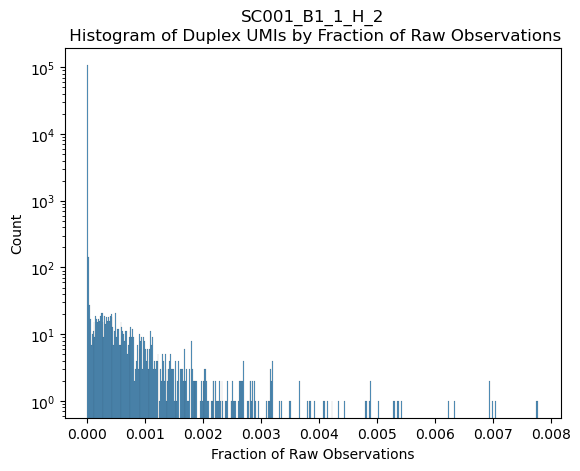

In [24]:
# plot cumsumative distribution of duplex UMIs (fraction_raw_observations)
sns.histplot(data=merged_umis, x="fraction_raw_observations", bins=500)
plt.xlabel("Fraction of Raw Observations")
plt.title(f"{sample}\n Histogram of Duplex UMIs by Fraction of Raw Observations")
# plt.xscale("log")
plt.yscale("log")
plt.show()

In [25]:
def plot_umi_frequencies(x, type_of_umi = "duplex", sample = "sample"):
    data = pd.DataFrame(x)
    data.columns = ["frequency"]
    data = data.reset_index()

    # plot cumsumative distribution of duplex UMIs (fraction_raw_observations)
    sns.lineplot(data=data, x="index", y="frequency")
    plt.xlabel(f"{type_of_umi.capitalize()} UMI Rank")
    plt.ylabel("Fraction of Raw Observations")
    plt.title(f"{sample}\nCumulative Distribution of {type_of_umi.capitalize()} UMIs")
    # plt.xlim(-100, 15000)
    plt.show()

In [27]:
merged_umis["fraction_unique_observations"]

0         0.006902
1         0.006847
2         0.006306
3          0.00624
4         0.006296
            ...   
109718         0.0
109719         0.0
109720         0.0
109721         0.0
109722     0.00859
Name: fraction_unique_observations, Length: 109723, dtype: object

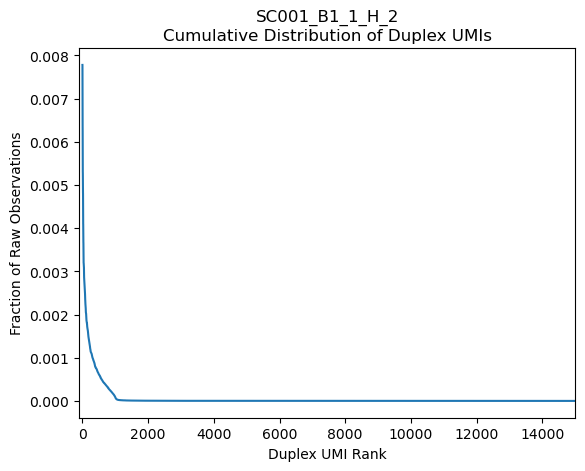

In [26]:
# plot cumsumative distribution of duplex UMIs (fraction_raw_observations)
sns.lineplot(data=merged_umis, x="index", y="fraction_raw_observations")
plt.xlabel("Duplex UMI Rank")
plt.ylabel("Fraction of Raw Observations")
plt.title(f"{sample}\nCumulative Distribution of Duplex UMIs")
plt.xlim(-100, 15000)
plt.show()

# REMOVE

## TEST -All molecules

In [ ]:
data = pd.read_csv(f"{run}/processing_files/sortbamamfiltered/{sample}.sorted.read_coords.head.tsv.gz",
                   sep="\t",
                   header=None)

In [ ]:
data.columns = ["READ_NAME", "CHROM", "START", "END"]
data.head(20)

,READ_NAME,CHROM,START,END
0,SC001_B1_1_H_2_chr1:1090,chr1,777639,777770
1,SC001_B1_1_H_2_chr1:1090,chr1,777586,777717
2,SC001_B1_1_H_2_chr1:1153,chr1,788768,788899
3,SC001_B1_1_H_2_chr1:1153,chr1,788738,788864
4,SC001_B1_1_H_2_chr1:1156,chr1,789009,789140
5,SC001_B1_1_H_2_chr1:1156,chr1,789241,789372
6,SC001_B1_1_H_2_chr1:1168,chr1,790199,790330
7,SC001_B1_1_H_2_chr1:1168,chr1,790018,790149
8,SC001_B1_1_H_2_chr1:1176,chr1,790940,791071
9,SC001_B1_1_H_2_chr1:1176,chr1,790850,790981


In [ ]:
merged_cuts = (
    data
    .groupby(["READ_NAME", "CHROM"])
    .agg(
        START_first=("START", "min"),
        END_first=("END", "min"),
        START_last=("START", "max"),
        END_last=("END", "max"),
    )
    .reset_index()
)

In [ ]:
first_in_pair = data.sort_values(by = ["READ_NAME", "CHROM", "START"]).drop_duplicates(subset=["READ_NAME"], keep='first')
last_in_pair = data.sort_values(by = ["READ_NAME", "CHROM", "START"]).drop_duplicates(subset=["READ_NAME"], keep='last')

In [ ]:
merged_cuts = first_in_pair.merge(last_in_pair, on=["READ_NAME", 'CHROM'], suffixes=("_first", "_last"))
merged_cuts

NameError: name 'first_in_pair' is not defined

In [ ]:
identical_cuts_size = merged_cuts.groupby(["CHROM", "START_first", "END_first", "START_last", "END_last"]).size()
frequency_identical_cuts_size = identical_cuts_size.to_frame().reset_index().rename(columns={0: "count"})
frequency_identical_cuts_size
# frequency_identical_cuts_size = identical_cuts_size.value_counts().to_frame().reset_index().rename(columns={"index": "repeats", 0: "count"})
# frequency_identical_cuts_size

,CHROM,START_first,END_first,START_last,END_last,count
0,chr1,777586,777717,777639,777770,1
1,chr1,788738,788864,788768,788899,1
2,chr1,789009,789140,789241,789372,1
3,chr1,790018,790149,790199,790330,1
4,chr1,790850,790981,790940,791071,1
...,...,...,...,...,...,...
468653,chr1,11210632,11210763,11210965,11211096,1
468654,chr1,11210632,11210763,11211009,11211140,1
468655,chr1,11210632,11210763,11211089,11211220,1
468656,chr1,11210657,11210747,11210887,11211017,1


In [ ]:
# merged_cuts[merged_cuts.duplicated(subset = ["START_first", "END_first", "START_last", "END_last"], keep=False)]

In [ ]:
frequency_identical_cuts_size["count"].value_counts().to_frame(
    name = 'frequency').reset_index().rename(
        columns={"count": "repeats"}).to_csv(
            f"{run}/processing_files/sortbamamfiltered/{sample}.sorted.read_coords.cuts_freq.tsv.gz",
            sep="\t", index=False, compression="gzip")

,repeats,frequency
0,1,440519
1,2,25405
2,3,2351
3,4,314
4,5,58
5,6,6
6,7,4
7,8,1
